# Advanced PDSCH Configuration and End-to-End Processing

This notebook demonstrates several advanced Physical Downlink Shared Channel (PDSCH) configuration options using **NeoRadium** and shows how these features affect resource mapping, transmission, channel estimation, and decoding.

The example configures a PDSCH transmission with:

- A **non-contiguous PRB allocation**
- **Interleaved resource allocation**
- **Reserved PRBs** that are excluded from PDSCH transmission
- Multiple **CSI-RS resources**
- **DMRS** and **PTRS** reference signals
- A **two-layer MIMO transmission**
- **LDPC channel coding**

The notebook first constructs and visualizes the PDSCH resource grid, highlighting how data, reference signals, CSI-RS resources, and reserved resource elements are mapped. Random transport blocks are then LDPC encoded, modulated, and mapped onto the configured PDSCH resources.

The transmitted signal is precoded and passed through a CDL fading channel with additive white Gaussian noise (AWGN). At the receiver, the notebook demonstrates two recovery approaches:

1. **Perfect channel knowledge**, using the exact effective channel matrix.
2. **Practical channel estimation**, using DMRS-based channel estimation and interpolation.

The recovered transport blocks are decoded and verified using CRC checks, while channel-estimation quality is evaluated through normalized mean-square error (NMSE) metrics. The notebook therefore provides a complete example of how advanced PDSCH configuration options interact within an end-to-end 5G NR downlink transmission chain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neoradium import BandwidthPart, PDSCH, AntennaPanel, CdlChannel, CsiRsConfig, ReservedPrbSet, random
from neoradium.utils import getNmse

In [2]:
random.setSeed(123)                                         # Make the results reproducible

# Create a bandwidth part
bwp = BandwidthPart(numRbs = 24,                            # 24 resource blocks
                    spacing = 30,                           # 30 kHz subcarrier spacing
                    interleavingBundleSize = 2)             # Enable interleaving with bundle size 2

# Create a reserved PRB set (all resource elements on OFDM symbol 8 in PRBs 0 and 6)
reservedPrbSet = ReservedPrbSet(bwp, prbs=[0,6], symbols=[8], pattern="0101")
# reservedPrbSet.print()                                    # Uncomment this to see details of reserved PRBs

# Create a CDL-C channel model
channel = CdlChannel(bwp, profile='C', delaySpread=100, carrierFreq=4e9, dopplerShift=10,
                     txAntenna=AntennaPanel([1,4], polarization='x', beamWidth=[65,65]),  # 8 TX antennas
                     rxAntenna=AntennaPanel([1,2], polarization='x', beamWidth=[65,360])) # 4 RX antennas (Omnidirectional)
# channel.print()                                           # Uncomment this to see details of the channel model

# Create a typical CSI-RS configuration for beam sweeping, beam probing, and CSI-feedback:
csiRsConfig = CsiRsConfig.beamformingConfig(bwp, channel.txAntenna.numPorts)
# csiRsConfig.print()                                       # Uncomment this to see details of CSI-RS configuration

# Create a 2-layer PDSCH
pdsch = PDSCH(bwp, numLayers=2,                             # Two transmission layers
              csiRsConfig=csiRsConfig,                      # The CSI-RS configuration
              reservedPrbSets=[reservedPrbSet],             # A list of 'ReservedPrbSet' objects
              prbSet=list(range(8))+list(range(16,24)),     # A non-contiguous set of PRBs: 0..7 , 16..23
              symStart=1, symLen=10,                        # Use OFDM symbols 1 to 10
              modulation="16QAM",                           # Modulation Scheme
              prgSize=2)                                    # enable precoding RB groups (PRGs) with size 2
# DM-RS configuration
pdsch.setDMRS(configType=1,                                 # Config Type 1 
              typeA1stPos=2,                                # First DMRS symbol is 2
              additionalPos=1,                              # One more symbol for DMRS (a total of 2 OFDM symbols)
              symbols=1,                                    # Single DMRS symbols
              numCdmGroupsWithoutData=2)                    # Make sure unused REs in the DMRS OFDM symbols are 
                                                            # not assigned to PDSCH.
# Create PT-RS
pdsch.setPTRS()                                             # Use all default PTRS settings

pdsch.print()                                               # Print PDSCH information



PDSCH Properties:
  mappingType:               A
  nID:                       1
  rnti:                      1
  numLayers:                 2
  numCodewords:              1
  modulation:                16QAM
  PRG Size:                  2
  portSet:                   0   1  
  symSet:                    1   2   3   4   5   6   7   8   9   10 
  prbSet:                    0   1   2   3   4   5   6   7   16  17  18  19  20  21  22  23 
  DMRS:
    configType:              1
    nIDs:                    []
    scID:                    0
    sameSeq:                 True
    symbols:                 Single
    typeA1stPos:             2
    additionalPos:           1
    cdmGroups (port:cdm):    0:0  1:0 
    deltaShifts (port:cdm):  0:0  1:0 
    numCdmGroupsWithoutData: 2
    symSet:                  2   9
    REs (before shift):      0 2 4 6 8 10
    epreRatioDb:             -3 (dB)
  PTRS:
    timeDensity:             1
    freqDensity:             2
    reOffset:                0
   

In [3]:
# Create an LDPC codec
ldpc = pdsch.getLdpcCodec(coderates=772/1024)               # Use the info already in PDSCH to create LDPC codec
ldpc.print()


LDPC Encode/Decode Properties:
  Num layers:         2
  Num codewords:      1
  numIter:            5
  nRef:               0
  Modulation:         16QAM
  Coderate:           772/1024
  TBS:                8712
  numLayers:          2
  Base Graph:         1
  Code Block Size:    4576
  Num Code Blocks:    2
  Lifting Size:       208



Number of resource elements:
  GridSize:       5376
  UNASSIGNED:     1536
  RESERVED:       48
  NO_DATA:        448
  PDSCH:          2640
  DMRS:           384
  PTRS:           64
  CSIRS_NZP(1):   32
  CSIRS_NZP(2):   32
  CSIRS_NZP(3):   32
  CSIRS_NZP(4):   32
  CSIRS_NZP(5):   32
  CSIRS_NZP(6):   32
  CSIRS_NZP(7):   32
  CSIRS_NZP(8):   32


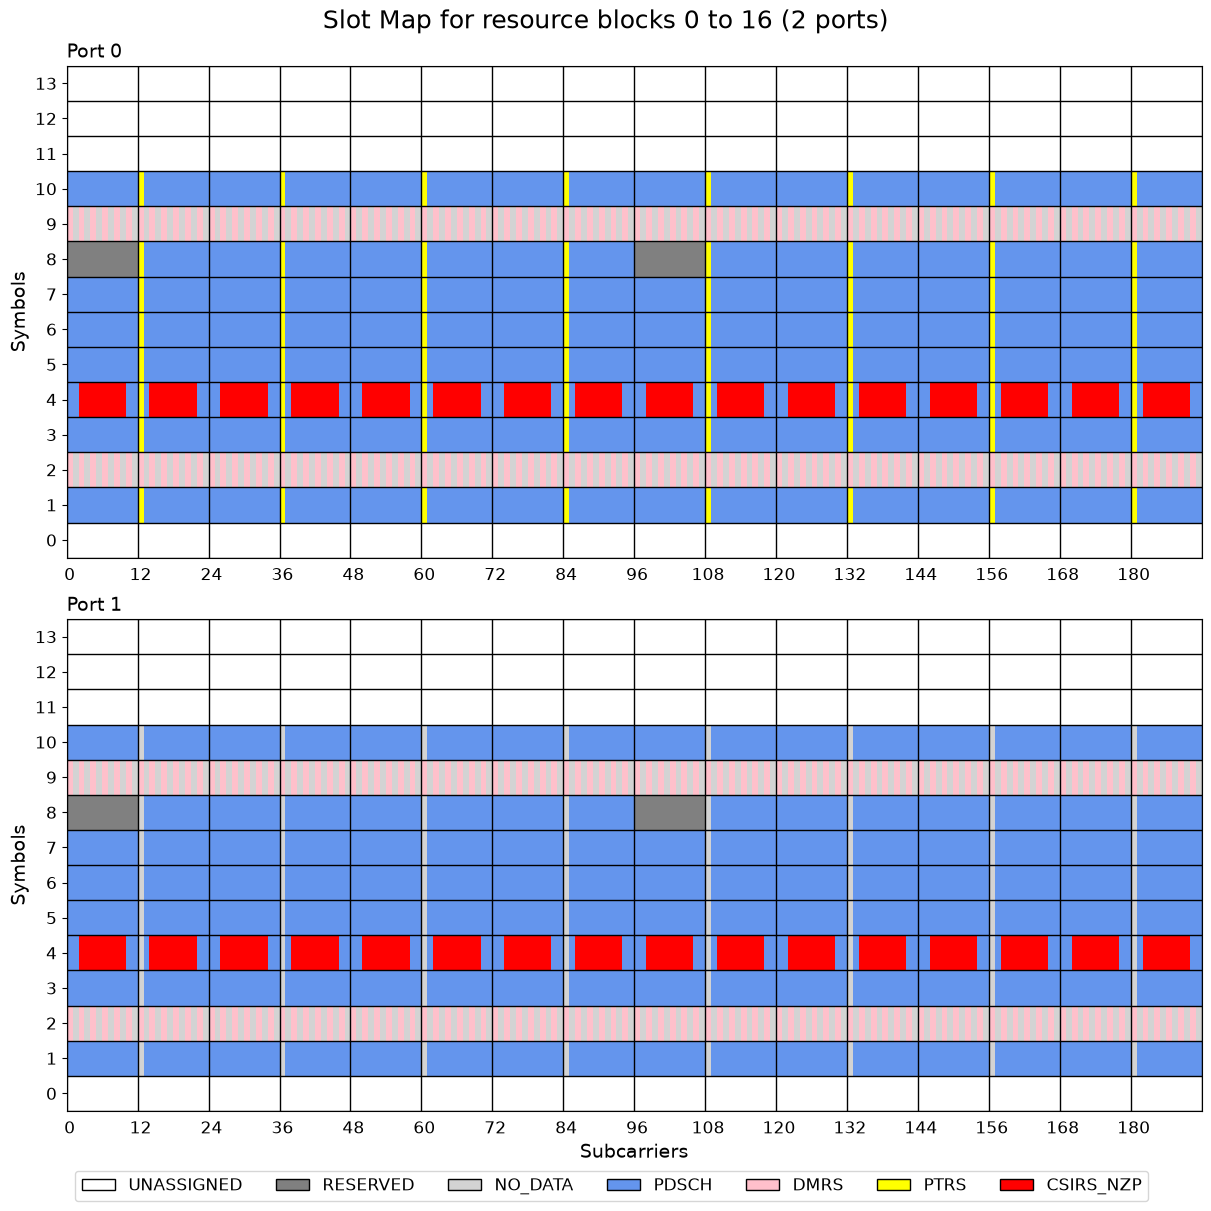

In [4]:
# Create and initialize PDSCH's internal resource grid, populate it with DM-RS and PT-RS, and 
# reserve REs for CSI-RS and reserved PRBs
pdsch.initGrid()

# Print statistics about the number of resource elements for each type of data in the PDSCH:
print("Number of resource elements:")
stats = pdsch.grid.getStats() 
for key, value in stats.items(): print(f"  {key+":":<15s} {value}")

# Draw a map of PDSCH's resource grid
pdsch.grid.drawMap(ports=[0,1],                             # Draw both layers (ports)
                   rbRange=(0,pdsch.grid.numRbs));          # Draw all PRBs in the grid


The figure above shows the PDSCH resource allocation before precoding and transmission. The grid contains two layers corresponding to the two configured PDSCH transmission layers.

* PDSCH occupies OFDM symbols 1 through 10.
* Resource blocks 0 and 8 are reserved in OFDM symbol 8. Recall that the reserved-PRB configuration was defined using PRBs 0 and 6. Because PRB interleaving is enabled, the resource blocks are rearranged, and PRB 6 maps to virtual resource block (VRB) 8. You can verify this by printing `pdsch.prb2Grb[6]`, which should return 8. The `prb2Grb` mapping translates physical resource blocks (PRBs) to GRBs, which are the resource-block indices used in the PDSCH's internal resource grid before interleaving. Later, after precoding and transmission-grid construction, you will see these resources mapped back to their configured PRB locations.
* DM-RS is present in OFDM symbols 2 and 9.
* The resource elements not occupied by DM-RS within the DM-RS symbols are marked as `NO_DATA` and cannot be used for PDSCH transmission. Try changing `numCdmGroupsWithoutData` to 1 and observe how the allocation of these resource elements changes.
* CSI-RS occupies OFDM symbol 4. In this symbol, eight resource elements within each resource block are allocated to CSI-RS.
* PT-RS is configured only on layer 0 (port 0).
* On layer 0, PT-RS is present in all PDSCH symbols except those that contain DM-RS.
* On layer 0, PT-RS is allocated to resource blocks 1, 3, 5, and so on. Within each of these resource blocks, PT-RS occupies the first resource element.
* On layer 1, all resource elements corresponding to PT-RS allocations on layer 0 are marked as `NO_DATA`. Consequently, these resource elements are not available for PDSCH transmission on layer 1.
* The PDSCH internal resource grid remains contiguous even though the transmission uses a non-contiguous PRB allocation. This becomes more apparent later when the resources are mapped from the internal grid to their final PRB locations in the transmitted resource grid.

In [5]:
numBits = pdsch.getBitCapacity()            # Number of PDSCH data bits in the resource grid for each codeword

# Create random transport block bitstreams for each codeword
txBlocks = [random.bits(tbs) for tbs in ldpc.txBlockSizes]  # Get TBS from the LDPC codec object for each codeword

# Perform LDPC rate-matching and encoding
rateMatchedCodeBlocks = ldpc.encode(txBlocks, numBits)  

# Map the encoded bitstreams to the PDSCH resource elements 
pdsch.setPdschData(rateMatchedCodeBlocks)

# Obtain a channel matrix from the channel model and derive a precoding matrix from it.
# Note that here we are assuming perfect channel knowledge for the precoding calculation
channelMatrix = channel.getChannelMatrix()
print(f"Shape of channel matrix: {' × '.join(str(x) for x in channelMatrix.shape)}")
# Since prgSize was set to two, the following precoder is a list of precoder matrices for 
# subbands of size 2 RBs. Each item in the list is a tuple of (groupPRBs, groupPrecoder)
precoder = pdsch.getPrecodingMatrix(channelMatrix)
print(f"Precoder has {len(precoder)} PRB groups. Shape of precoder for each PRB group: {precoder[0][1].shape[0]} × {precoder[0][1].shape[1]}")


Shape of channel matrix: 14 × 288 × 4 × 8
Precoder has 8 PRB groups. Shape of precoder for each PRB group: 8 × 2


Shape of transmitted resource grid: 8 × 14 × 288


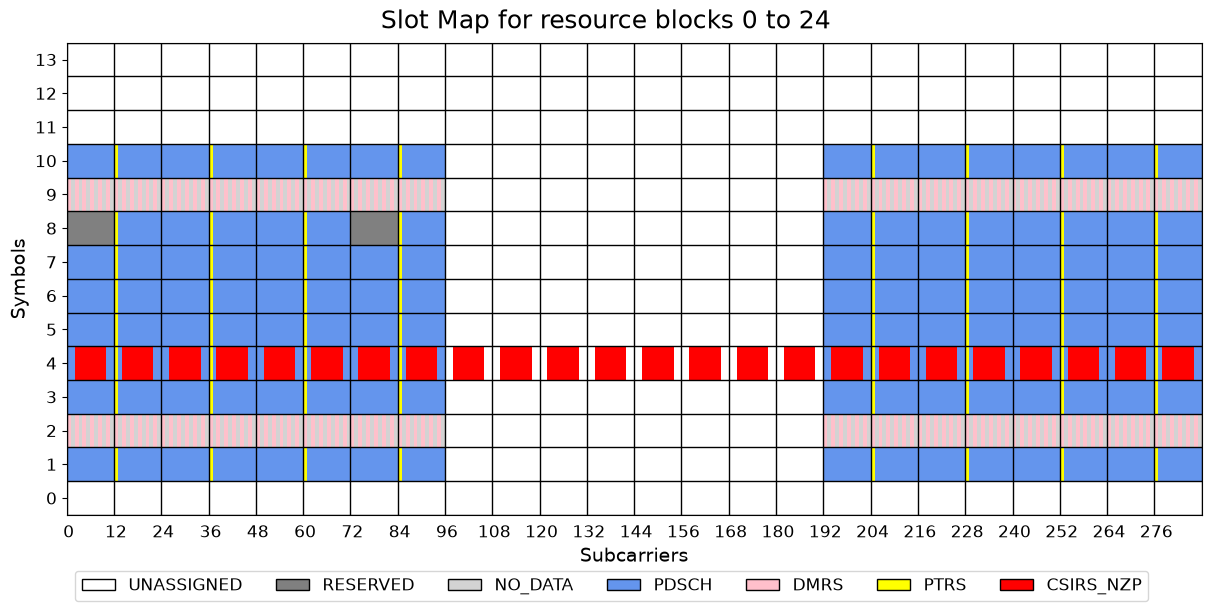

In [6]:
# Create a transmitted resource grid:
txGrid = bwp.createGrid(channel.txAntenna.numPorts)
print(f"Shape of transmitted resource grid: {' × '.join(str(x) for x in txGrid.shape)}")

# Map and precode the PDSCH onto the transmitted resource grid. Interleaving and VRB to PRB mapping happen here.
pdsch.precodeTo(txGrid, precoder)

# Now we need to set the CSI-RS values in the transmitted resource grid. Note that CSI-RS is independent of the PDSCH allocation.
# We first get the CSI-RS resources for current slot of communication. Since the first set of CSI-RS resources are used for
# beam sweeping, we get a set of beams and their corresponding precoders using the AntennaPanel's 'getSweepingBeams' function.
# We then precode the CSI-RS values using each beam's precoder and place the precoded CSI-RS symbols into 'txGrid'.
csiResources = csiRsConfig.getResources()
csiRsPrecoders, beams = channel.txAntenna.getSweepingBeams(1, 8, polStrategy="equal")
for csiSetId, setResources in csiResources.items():
    for b, (resourceId, (lIdx, kIdx, csiRsValues)) in enumerate(setResources.items()):
        # Sweeping CSI-RS use only one port. Precoder shape is: numTxAntenna x 1
        # CSI-RS values for each CSI-RS resource is a 1 x numREs vector where numREs are the number of CSI-RS resource elements
        # The precoded matrix's shape is: numTxAntenna x numREs which is copied to the transmitted resource grid.
        txGrid[:,lIdx, kIdx] = (csiRsPrecoders[:,b:b+1] @ csiRsValues, "CSIRS_NZP", resourceId)   

# Draw the PRB map of the transmitted resource grid (first antenna port only)
txGrid.drawMap(rbRange=(0,txGrid.numRbs));

The figure above shows the transmitted resource grid after precoding. Unlike the previous allocation map, this grid contains the actual complex-valued symbols that will be transmitted from each antenna port.

* The figure shows the transmitted resource grid in physical resource block (PRB) order.
* As configured, the PDSCH occupies PRBs 0 through 7 and PRBs 16 through 23.
* The reserved resources appear in their configured PRB locations, namely PRBs 0 and 6.
* PDSCH, DM-RS, and PT-RS resources are distributed across the bandwidth according to the configured interleaving pattern.
* CSI-RS occupies resource elements across all PRBs, including those that are not allocated to the PDSCH.

This is the signal representation that is ultimately converted to the time domain, transmitted through the wireless channel, and processed by the receiver.

Shape of the noisy received resource grid: 4 × 14 × 288


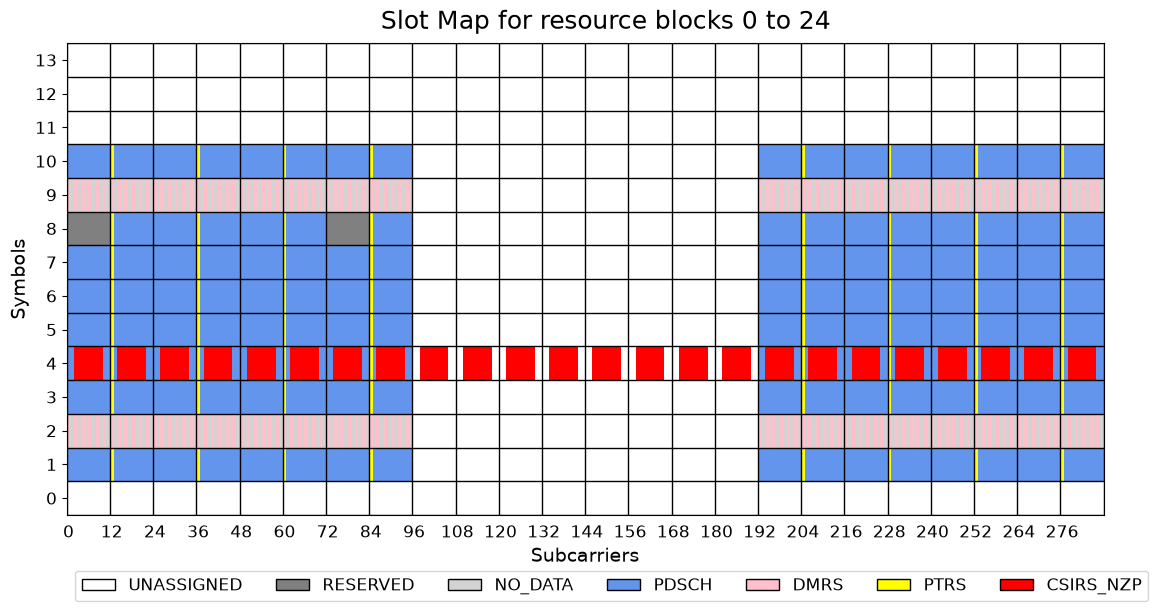

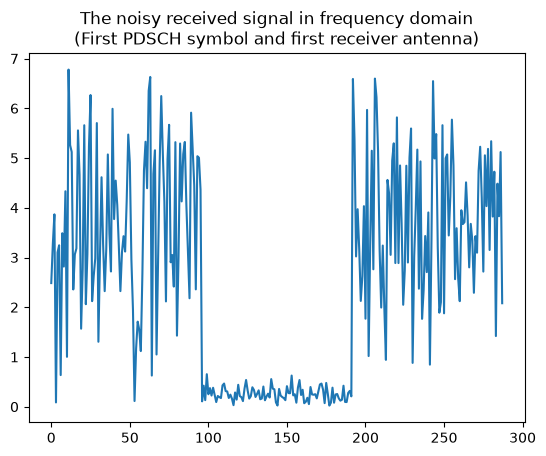

In [7]:
# Apply the CDL channel model to the transmitted resource grid in frequency domain
rxGrid = txGrid.applyChannel(channelMatrix)

# Add AWGN noise to get a noisy received resource grid
noisyRxGrid = rxGrid.addNoise(snrDb=5)   
print(f"Shape of the noisy received resource grid: {' × '.join(str(x) for x in noisyRxGrid.shape)}")

# Draw the PRB map of the noisy received resource grid (first antenna port only)
rxGrid.drawMap(rbRange=(0,noisyRxGrid.numRbs))
plt.show()

# Visualize the noisy received signal on the first receive antenna in the frequency domain
plt.plot(np.abs(noisyRxGrid[0,1,:]))
plt.title("The noisy received signal in frequency domain\n(First PDSCH symbol and first receiver antenna)")
plt.show()

In [8]:
# Assuming perfect channel knowledge, we can get the effective channel matrix using the 'getEffChannel' 
# function of the channel model. This effective channel includes the effects of precoding.
# In practice, this channel is estimated using reference signals such as DM-RS.
effChannelMatrix = channel.getEffChannel(channelMatrix, precoder)
print(f"Shape of the effective channel matrix: {' × '.join(str(x) for x in effChannelMatrix.shape)}")

# Equalize the noisy received resource grid
eqGrid, llrScales = pdsch.equalize(noisyRxGrid, effChannelMatrix)

# Demodulate to get log-likelihood ratios (LLRs)
llrs = pdsch.getLLRs(eqGrid, llrScales)

# Perform LDPC rate-recovery and decoding:
decodedTxBlocks, crcMatch = ldpc.decode(llrs)
print(f"Transport block CRC match:         {crcMatch[0][0]}")
print(f"CRC matches for the code block(s): {crcMatch[0][1:]}")


Shape of the effective channel matrix: 14 × 288 × 4 × 2
Transport block CRC match:         True
CRC matches for the code block(s): [ True  True]


In [9]:
# We can also estimate the channel using DM-RS signals. The PDSCH's 'estimateChannel' method is
# used here to estimate channel, and the the estimated channel matrix is used to equalize and decode
# the received resource grid.
estChannelMatrix, errVar = pdsch.estimateChannel(noisyRxGrid)
print(f"NMSE between the estimated and perfect channel (All PRBs):  "
      f"{getNmse(effChannelMatrix, estChannelMatrix):.3f}")

# Since only the PRBs used by PDSCH are important, we can compare the channel matrices
# only in those PRBs.
preSet = (pdsch.prbSet[:,None]*12+np.arange(12)).flatten()      # subcarriers used by PDSCH
print(f"NMSE between the estimated and perfect channel (PDSCH RBs): "
      f"{getNmse(effChannelMatrix[:,preSet], estChannelMatrix[:,preSet]):.3f}")

# Equalize the noisy received resource grid using the estimated channel matrix
# Note that in this case we must use the 'errVar' returned by 'estimateChannel' for equalization
eqGridEst, llrScales = pdsch.equalize(noisyRxGrid, estChannelMatrix, errVar)
print(f"NMSE between the equalized and the original resource grid:  "
      f"{getNmse(eqGridEst.grid, pdsch.grid.grid):.3f}\n")

# Demodulate to get log-likelihood ratios (LLRs)
llrs = pdsch.getLLRs(eqGridEst, llrScales)

# Perform LDPC rate-recovery and decoding
decodedTxBlocks, crcMatch = ldpc.decode(llrs)
print(f"Transport block CRC match:         {crcMatch[0][0]}")
print(f"CRC matches for the code block(s): {crcMatch[0][1:]}")


NMSE between the estimated and perfect channel (All PRBs):  0.719
NMSE between the estimated and perfect channel (PDSCH RBs): 0.004
NMSE between the equalized and the original resource grid:  0.196

Transport block CRC match:         True
CRC matches for the code block(s): [ True  True]
